# About Tha Data

link https://www.kaggle.com/datasets/fahadullaha/facial-emotion-recognition-dataset/data


This was a data source for a university project. This dataset was processed using FER2013 Dataset and RAFDB Dataset. Using various techniques like HaarCascade for filtering images with a face (at 0.8 confidence score), lower noise. The datasets were merged and the gray scale images from FER2013 was converted to RGB. This dataset provides a rich mix of images across 7 emotions. Note: Direct use of the dataset will cause issues due to class imbalance among the dataset classes.

## Imports

In [1]:
import numpy as np
import pandas as pd
import kagglehub
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
tf.get_logger().setLevel('ERROR')


## Load The Data

In [2]:
# Download latest version
path = kagglehub.dataset_download("fahadullaha/facial-emotion-recognition-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'facial-emotion-recognition-dataset' dataset.
Path to dataset files: /kaggle/input/facial-emotion-recognition-dataset


In [3]:
IMAGE_SIZE = 96
BATCH_SIZE = 32
DATASET_DIR = '/root/.cache/kagglehub/datasets/fahadullaha/facial-emotion-recognition-dataset/versions/1/processed_data'

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

class_names = dataset.class_names
n_classes = len(class_names)
print("Classes:", class_names)

Found 49779 files belonging to 7 classes.
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## Explore A Bit

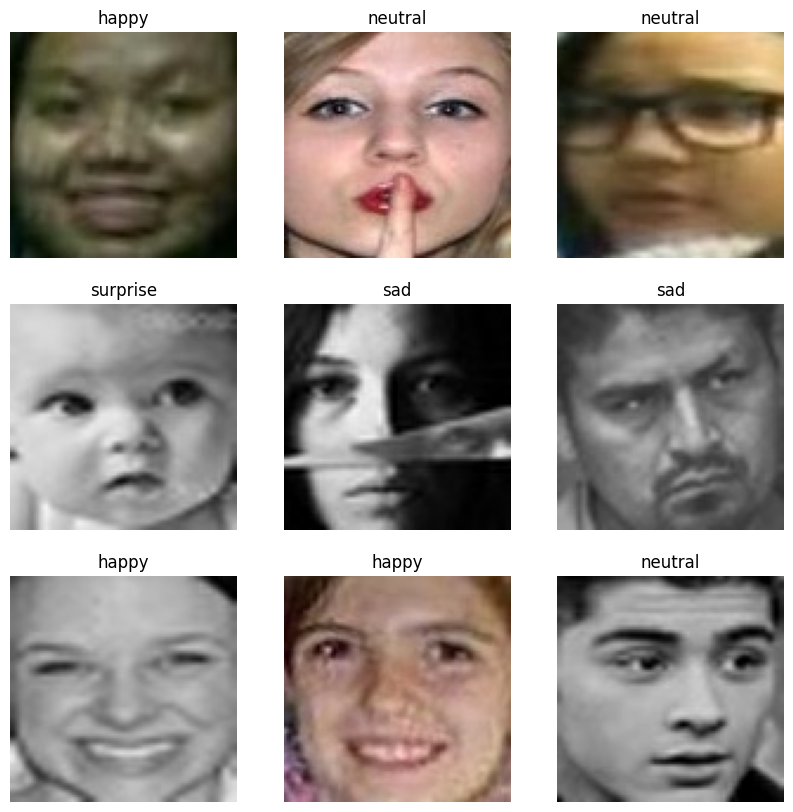

In [4]:
import matplotlib.pyplot as plt

# Take one batch from the dataset
for images, labels in dataset.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.show()

## Train Test Validation

In [5]:
dataset_size = len(list(dataset))
train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)

train_ds = dataset.take(train_size)
remaining = dataset.skip(train_size)
val_ds = remaining.take(val_size)
test_ds = remaining.skip(val_size)

print("Train batches:", len(train_ds))
print("Validation batches:", len(val_ds))
print("Test batches:", len(test_ds))

Train batches: 1244
Validation batches: 155
Test batches: 157


## Pipeline

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Data Augmentation

In [7]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
], name="aug")

## Model EfficientNetB0/B3

In [8]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(96,96,3)
)
base_model.trainable = False  # first freeze

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation='softmax')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False


In [10]:
model = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(96,96,3)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(n_classes, activation='softmax')
])

In [11]:

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05
EPOCHS = 50

In [12]:
optimizer = keras.optimizers.AdamW(
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

loss = keras.losses.CategoricalCrossentropy(
    label_smoothing=LABEL_SMOOTHING
)

metrics = [
    "accuracy",
    keras.metrics.TopKCategoricalAccuracy(k=2, name="top2_acc")
]

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [14]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1),
    ModelCheckpoint('best_model.h5', save_best_only=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
    verbose=2
)

Epoch 1/20


1244/1244 - 90s - 72ms/step - accuracy: 0.4232 - loss: 1.6242 - val_accuracy: 0.4960 - val_loss: 1.4032 - learning_rate: 1.0000e-03
Epoch 2/20


1244/1244 - 62s - 50ms/step - accuracy: 0.5420 - loss: 1.2122 - val_accuracy: 0.5413 - val_loss: 1.2100 - learning_rate: 1.0000e-03
Epoch 3/20


1244/1244 - 67s - 54ms/step - accuracy: 0.5761 - loss: 1.1222 - val_accuracy: 0.5639 - val_loss: 1.1434 - learning_rate: 1.0000e-03
Epoch 4/20
1244/1244 - 60s - 48ms/step - accuracy: 0.6200 - loss: 1.0090 - val_accuracy: 0.1728 - val_loss: 3.9564 - learning_rate: 1.0000e-03
Epoch 5/20


1244/1244 - 62s - 50ms/step - accuracy: 0.6501 - loss: 0.9351 - val_accuracy: 0.5845 - val_loss: 1.1007 - learning_rate: 1.0000e-03
Epoch 6/20


1244/1244 - 71s - 57ms/step - accuracy: 0.6986 - loss: 0.8183 - val_accuracy: 0.6117 - val_loss: 1.0470 - learning_rate: 1.0000e-03
Epoch 7/20
1244/1244 - 59s - 48ms/step - accuracy: 0.7383 - loss: 0.7099 - val_accuracy: 0.6236 - val_loss: 1.0966 - learning_rate: 1.0000e-03
Epoch 8/20
1244/1244 - 59s - 47ms/step - accuracy: 0.7988 - loss: 0.5538 - val_accuracy: 0.6266 - val_loss: 1.1115 - learning_rate: 1.0000e-03
Epoch 9/20

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
1244/1244 - 59s - 47ms/step - accuracy: 0.8368 - loss: 0.4557 - val_accuracy: 0.6083 - val_loss: 1.2782 - learning_rate: 1.0000e-03
Epoch 10/20
1244/1244 - 59s - 47ms/step - accuracy: 0.9119 - loss: 0.2588 - val_accuracy: 0.6665 - val_loss: 1.0527 - learning_rate: 2.0000e-04
Epoch 11/20
1244/1244 - 59s - 47ms/step - accuracy: 0.9394 - loss: 0.1864 - val_accuracy: 0.6716 - val_loss: 1.0927 - learning_rate: 2.0000e-04


157/157 - 24s - 152ms/step - accuracy: 0.6266 - loss: 1.0104
✅ Test Accuracy: 62.66%


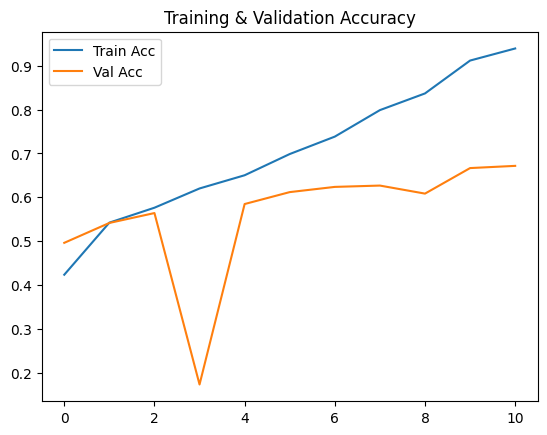

In [16]:
loss, acc = model.evaluate(test_ds,verbose=2)
print(f"✅ Test Accuracy: {acc*100:.2f}%")

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Training & Validation Accuracy")
plt.show()

## Confusion Matrix

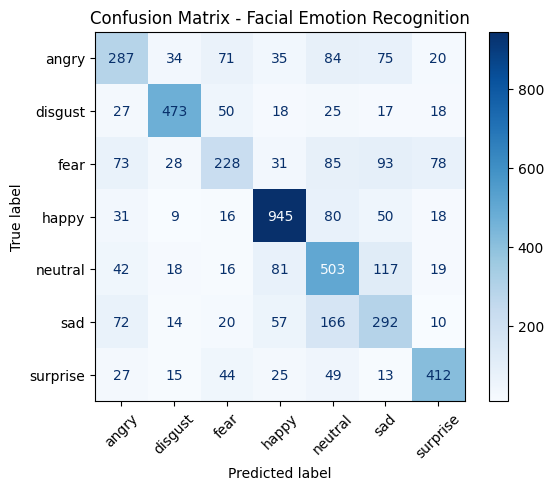

In [17]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images,verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45, cmap='Blues')
plt.title("Confusion Matrix - Facial Emotion Recognition")
plt.show()